
DATASET PREVIEW (First 5 Rows)
  decision_type  age  gender education risk_level  perceived_accuracy  \
0            AI   50    Male        PG        Low           78.078018   
1         Human   18  Female        UG        Low           57.898316   
2            AI   36  Female        PG       High           61.518146   
3            AI   19    Male        UG       High           82.432641   
4            AI   43    Male       PhD     Medium           76.708654   

   trust_score  
0     7.827403  
1     7.041570  
2     7.170774  
3     9.770724  
4     9.273052  

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   decision_type       300 non-null    object 
 1   age                 300 non-null    int64  
 2   gender              300 non-null    object 
 3   education           300 non-null    object 
 4   ris

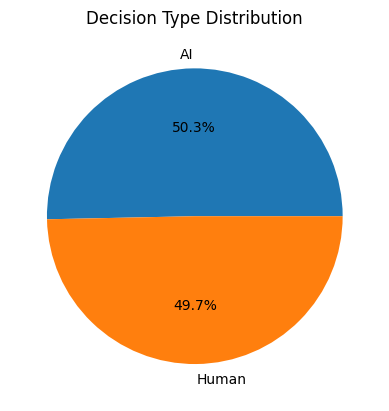

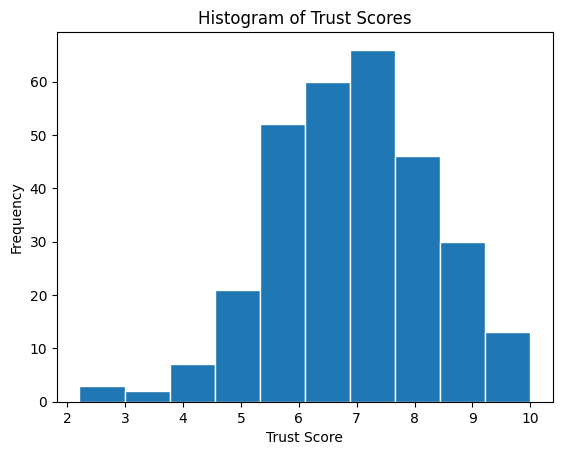

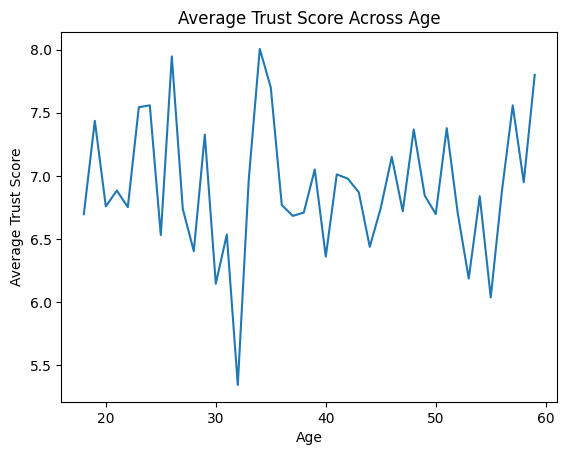

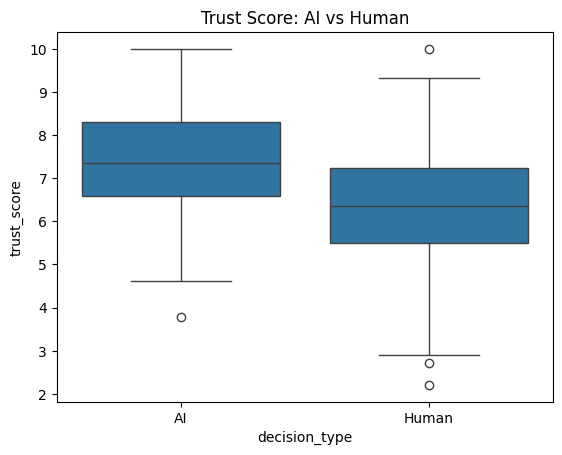

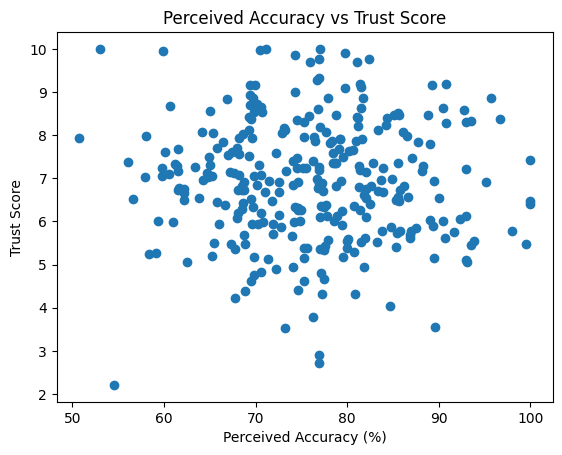


MEASURES OF CENTRAL TENDENCY
Mean Trust Score: 6.921080018024142
Median Trust Score: 6.917078586576544
Mode Trust Score: 10.0

MEASURES OF DISPERSION
Range: 7.78989067689245
Variance: 1.955845565199557
Standard Deviation: 1.398515486220856
Interquartile Range: 1.9332089657116196
Coefficient of Variation (%): 20.206607676530083

SKEWNESS & KURTOSIS
Skewness: -0.15698762108864747
Kurtosis: 0.15408293386716787

CORRELATION ANALYSIS
Pearson Correlation (Accuracy vs Trust): -0.025296312463522447
Spearman Correlation (Age vs Trust): -0.01247786897556569

LINEAR REGRESSION MODEL
Trust Score = 7.204366626831308 + -0.0037191990033830324 * Perceived Accuracy


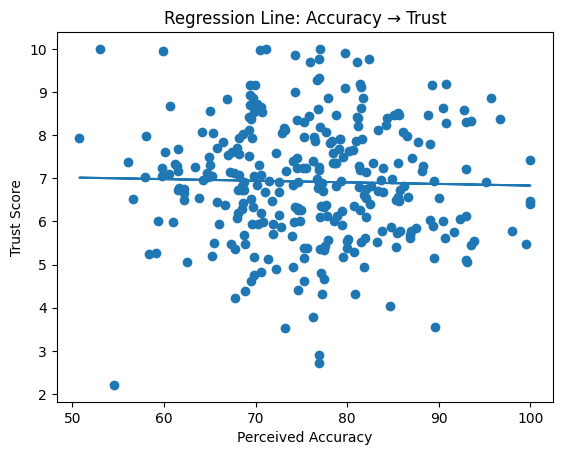


PROBABILITY
P(Trust Score > 7): 0.47333333333333333
P(High Trust | AI Decision): 0.6291390728476821


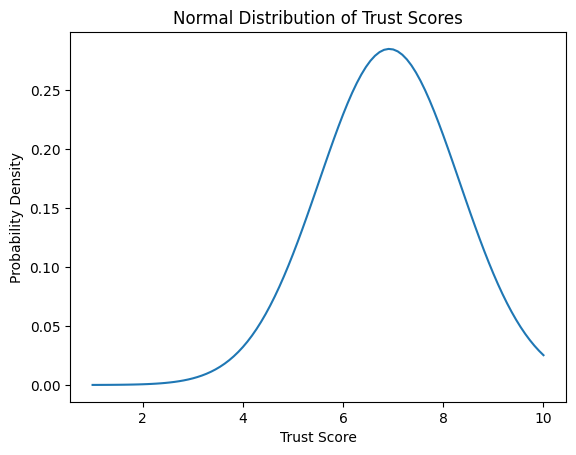

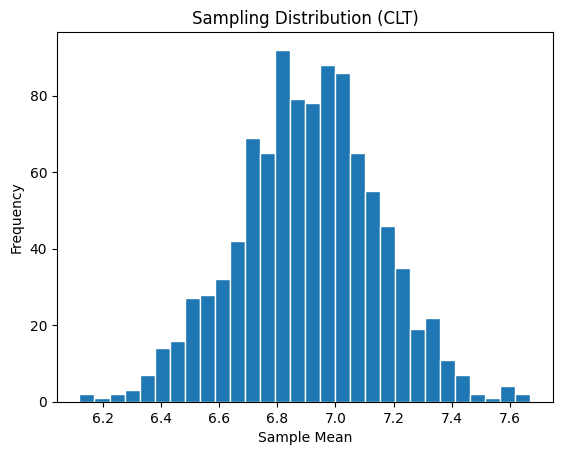


HYPOTHESIS TESTING
t-statistic: 6.86758544038452
p-value: 3.805745375568122e-11
Conclusion: Significant difference in trust between AI and Human decisions.


In [4]:
# ============================================================
# PROJECT TITLE:
# Trust in AI vs Human Decision-Making: A Statistical Study
# ============================================================

# ------------------------------------------------------------
# STEP 0: Import required libraries
# ------------------------------------------------------------
# numpy  -> numerical operations
# pandas -> data handling and table creation
# matplotlib -> plotting graphs
# seaborn -> statistical plots
# scipy.stats -> statistical formulas (correlation, t-test etc.)
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Fixing random seed so results are reproducible
np.random.seed(42)

# ------------------------------------------------------------
# STEP 1: DATA GENERATION (Population & Sample)
# ------------------------------------------------------------
# Sample size = 300 respondents
# ------------------------------------------------------------

n = 300

# Creating a DataFrame with different variable types
data = pd.DataFrame({
    "decision_type": np.random.choice(["AI", "Human"], n),          # Nominal
    "age": np.random.randint(18, 60, n),                            # Ratio
    "gender": np.random.choice(["Male", "Female"], n),              # Nominal
    "education": np.random.choice(["UG", "PG", "PhD"], n),           # Ordinal
    "risk_level": np.random.choice(["Low", "Medium", "High"], n),   # Ordinal
    "perceived_accuracy": np.random.normal(75, 10, n)               # Ratio
})

# Trust score depends on decision type
data["trust_score"] = np.where(
    data["decision_type"] == "AI",
    np.random.normal(7.2, 1.2, n),
    np.random.normal(6.3, 1.4, n)
)

# Restricting values within realistic bounds
data["trust_score"] = data["trust_score"].clip(1, 10)
data["perceived_accuracy"] = data["perceived_accuracy"].clip(40, 100)

# ------------------------------------------------------------
# STEP 2: DATASET OVERVIEW (VERY IMPORTANT FOR PROJECT)
# ------------------------------------------------------------
# Showing first few rows of dataset
# Helps examiner understand what data looks like
# ------------------------------------------------------------

print("\nDATASET PREVIEW (First 5 Rows)")
print(data.head())

# ------------------------------------------------------------
# Displaying dataset structure and data types
# ------------------------------------------------------------

print("\nDATASET INFORMATION")
print(data.info())

# ------------------------------------------------------------
# Statistical summary of numerical columns
# ------------------------------------------------------------

print("\nDATASET DESCRIPTION")
print(data.describe())

# ------------------------------------------------------------
# STEP 3: DATA VISUALIZATION
# ------------------------------------------------------------

# ---------- PIE CHART ----------
# Shows proportion of AI vs Human decisions
plt.figure()
data["decision_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    title="Decision Type Distribution"
)
plt.ylabel("")
plt.show()

# ---------- HISTOGRAM ----------
# Shows frequency distribution of trust scores
plt.figure()
plt.hist(data["trust_score"], bins=10, edgecolor="white")
plt.title("Histogram of Trust Scores")
plt.xlabel("Trust Score")
plt.ylabel("Frequency")
plt.show()

# ---------- LINE GRAPH ----------
# Shows average trust score across age
avg_trust_by_age = data.groupby("age")["trust_score"].mean()

plt.figure()
plt.plot(avg_trust_by_age)
plt.title("Average Trust Score Across Age")
plt.xlabel("Age")
plt.ylabel("Average Trust Score")
plt.show()

# ---------- BOX PLOT ----------
# Comparison of trust between AI and Human decisions
plt.figure()
sns.boxplot(x="decision_type", y="trust_score", data=data)
plt.title("Trust Score: AI vs Human")
plt.show()

# ---------- SCATTER PLOT ----------
# Relationship between perceived accuracy and trust
plt.figure()
plt.scatter(data["perceived_accuracy"], data["trust_score"])
plt.xlabel("Perceived Accuracy (%)")
plt.ylabel("Trust Score")
plt.title("Perceived Accuracy vs Trust Score")
plt.show()

# ------------------------------------------------------------
# STEP 4: MEASURES OF CENTRAL TENDENCY
# ------------------------------------------------------------

mean_trust = data["trust_score"].mean()      # Arithmetic mean
median_trust = data["trust_score"].median()  # Middle value
mode_trust = data["trust_score"].mode()[0]   # Most frequent value

print("\nMEASURES OF CENTRAL TENDENCY")
print("Mean Trust Score:", mean_trust)
print("Median Trust Score:", median_trust)
print("Mode Trust Score:", mode_trust)

# ------------------------------------------------------------
# STEP 5: MEASURES OF DISPERSION
# ------------------------------------------------------------

range_trust = data["trust_score"].max() - data["trust_score"].min()
variance_trust = data["trust_score"].var()
std_dev_trust = data["trust_score"].std()
iqr_trust = stats.iqr(data["trust_score"])
cv_trust = (std_dev_trust / mean_trust) * 100

print("\nMEASURES OF DISPERSION")
print("Range:", range_trust)
print("Variance:", variance_trust)
print("Standard Deviation:", std_dev_trust)
print("Interquartile Range:", iqr_trust)
print("Coefficient of Variation (%):", cv_trust)

# ------------------------------------------------------------
# STEP 6: SKEWNESS & KURTOSIS
# ------------------------------------------------------------

skewness = data["trust_score"].skew()
kurtosis = data["trust_score"].kurt()

print("\nSKEWNESS & KURTOSIS")
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

# ------------------------------------------------------------
# STEP 7: CORRELATION ANALYSIS
# ------------------------------------------------------------

pearson_corr, _ = stats.pearsonr(
    data["perceived_accuracy"], data["trust_score"]
)

spearman_corr, _ = stats.spearmanr(
    data["age"], data["trust_score"]
)

print("\nCORRELATION ANALYSIS")
print("Pearson Correlation (Accuracy vs Trust):", pearson_corr)
print("Spearman Correlation (Age vs Trust):", spearman_corr)

# ------------------------------------------------------------
# STEP 8: REGRESSION ANALYSIS
# ------------------------------------------------------------

slope, intercept, r, p, err = stats.linregress(
    data["perceived_accuracy"],
    data["trust_score"]
)

print("\nLINEAR REGRESSION MODEL")
print("Trust Score =", intercept, "+", slope, "* Perceived Accuracy")

# Regression graph
plt.figure()
plt.scatter(data["perceived_accuracy"], data["trust_score"])
plt.plot(
    data["perceived_accuracy"],
    intercept + slope * data["perceived_accuracy"]
)
plt.xlabel("Perceived Accuracy")
plt.ylabel("Trust Score")
plt.title("Regression Line: Accuracy → Trust")
plt.show()

# ------------------------------------------------------------
# STEP 9: PROBABILITY
# ------------------------------------------------------------

# Classical probability
prob_high_trust = len(data[data["trust_score"] > 7]) / len(data)
print("\nPROBABILITY")
print("P(Trust Score > 7):", prob_high_trust)

# Conditional probability
cond_prob = (
    len(data[(data["decision_type"]=="AI") & (data["trust_score"]>7)])
    / len(data[data["decision_type"]=="AI"])
)

print("P(High Trust | AI Decision):", cond_prob)

# ------------------------------------------------------------
# STEP 10: PROBABILITY DISTRIBUTION (Normal)
# ------------------------------------------------------------

mu = data["trust_score"].mean()
sigma = data["trust_score"].std()

x = np.linspace(1, 10, 100)

plt.figure()
plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.title("Normal Distribution of Trust Scores")
plt.xlabel("Trust Score")
plt.ylabel("Probability Density")
plt.show()

# ------------------------------------------------------------
# STEP 11: SAMPLING & CENTRAL LIMIT THEOREM
# ------------------------------------------------------------

sample_means = []

for i in range(1000):
    sample = data["trust_score"].sample(30)
    sample_means.append(sample.mean())

plt.figure()
plt.hist(sample_means, bins=30, edgecolor="white")
plt.title("Sampling Distribution (CLT)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------------------
# STEP 12: HYPOTHESIS TESTING (Independent t-test)
# ------------------------------------------------------------

ai_trust = data[data["decision_type"]=="AI"]["trust_score"]
human_trust = data[data["decision_type"]=="Human"]["trust_score"]

t_stat, p_val = stats.ttest_ind(ai_trust, human_trust)

print("\nHYPOTHESIS TESTING")
print("t-statistic:", t_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("Conclusion: Significant difference in trust between AI and Human decisions.")
else:
    print("Conclusion: No significant difference in trust.")

# ============================================================
# END OF STATISTICAL PROJECT
# ============================================================
